# (advanced) using a custom background mesh for native-space visualization

This notebook demonstrates how to generate a background mesh from a nifti image and use it in the `plot_subcortical()` and `plot_tracts()` functions.

**Why using a custom background mesh?**
In the case where your data lives in a different space than a template space (such as fsaverage), using the template as the background might lead unaligned structures. To circumvent this issue, we can generate a glass brain to use as background mesh from a nifti image.

### inputs and outputs

**we start with:**
1.  **atlas volume (`.nii.gz`):** the 3D NIfTI file where each voxel contains an integer region ID.
2.  **atlas metadata (`.txt`, `.csv`, etc.):** a file listing the string names for each integer ID. *(note: because every atlas creator formats this differently, we will write a quick loop to parse this into a python dictionary before feeding it to the builder).*
3. **tractography geometry (`.trk` or `.tck`):** the streamline files.
4.  **nifti image (`.nii.gz`):** the 3D NIfTI file to use to build the background mesh. Can be a preprocessed anatomical image, brain mask, etc.

**we need to generate:**
1. **surface meshes (`.vtk`):** a dedicated folder containing individual 3D mesh files for every extracted subcortical regions. A complete tutorial is available in `docs/tutorials/custom_subcortical_atlas.ipynb`.
2. **background mesh:** a mesh derived from a nifti file.

In [6]:
# Define imports
import os
import pooch
import yabplot as yab

# Using a custom background mesh for subcortical atlas visualization

A complete guide is a available in `docs/tutorials/custom_subcortical_atlas.ipynb`, so redundant steps will be only briefly introduced here.

## Step 1: Configuration, metadata parsing, filtering, and atlas creation.

In [ ]:
# define where your source NIfTI and text files are located
# you can download the same atlas for this tutorial in here:
# https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz
aal_txt = "/Users/anthonygagnon/Downloads/AAL3/AAL3v1_1mm.nii.txt"
aal_nii = "/Users/anthonygagnon/Downloads/AAL3/AAL3v1_1mm.nii.gz"
# Define output folder for reconstructed meshes.
dir_full_subcortical = "./subcortical/AAL3v1"

# This section parses the AAL3 text file into a standard python dictionary mapping integers IDs to region names.
atlas_labels = {}

with open(aal_txt, 'r') as f_in:
    for line in f_in:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                rid = int(parts[0])
                name = parts[1].replace(' ', '_').replace('/', '-')
                atlas_labels[rid] = name
            except ValueError:
                continue

print(f"successfully parsed {len(atlas_labels)} total regions from text file.")
print(atlas_labels)

# Filtering the atlas labels to extract subcortical regions and cerebellar regions.
# define all subcortical keywords present in the mixed AAL3 atlas
subcortical_keywords = [
    'Hippocampus', 'Amygdala', 'Caudate', 'Putamen', 'Pallidum', 'Thalamus', 'Thal',
    'Cerebellum', 'Vermis', 'N_Acc', 'VTA', 'SN', 'Red_N', 'LC', 'Raphe'
]

print("--- building atlas 1: full subcortical (using include_list) ---")
yab.build_subcortical_atlas(
    nii_path=aal_nii,
    labels_dict=atlas_labels,
    out_dir=dir_full_subcortical,
    include_list=subcortical_keywords,
    smooth_i=20, smooth_f=0.7
)

# check the amount of regions
regions_full = yab.get_atlas_regions(atlas=None, category='subcortical', custom_atlas_path=dir_full_subcortical)
print(f"full atlas: found {len(regions_full)} meshes.")

successfully parsed 170 total regions from text file.
{1: 'Precentral_L', 2: 'Precentral_R', 3: 'Frontal_Sup_2_L', 4: 'Frontal_Sup_2_R', 5: 'Frontal_Mid_2_L', 6: 'Frontal_Mid_2_R', 7: 'Frontal_Inf_Oper_L', 8: 'Frontal_Inf_Oper_R', 9: 'Frontal_Inf_Tri_L', 10: 'Frontal_Inf_Tri_R', 11: 'Frontal_Inf_Orb_2_L', 12: 'Frontal_Inf_Orb_2_R', 13: 'Rolandic_Oper_L', 14: 'Rolandic_Oper_R', 15: 'Supp_Motor_Area_L', 16: 'Supp_Motor_Area_R', 17: 'Olfactory_L', 18: 'Olfactory_R', 19: 'Frontal_Sup_Medial_L', 20: 'Frontal_Sup_Medial_R', 21: 'Frontal_Med_Orb_L', 22: 'Frontal_Med_Orb_R', 23: 'Rectus_L', 24: 'Rectus_R', 25: 'OFCmed_L', 26: 'OFCmed_R', 27: 'OFCant_L', 28: 'OFCant_R', 29: 'OFCpost_L', 30: 'OFCpost_R', 31: 'OFClat_L', 32: 'OFClat_R', 33: 'Insula_L', 34: 'Insula_R', 35: 'Cingulate_Ant_L', 36: 'Cingulate_Ant_R', 37: 'Cingulate_Mid_L', 38: 'Cingulate_Mid_R', 39: 'Cingulate_Post_L', 40: 'Cingulate_Post_R', 41: 'Hippocampus_L', 42: 'Hippocampus_R', 43: 'ParaHippocampal_L', 44: 'ParaHippocampal_R', 

## Step 2: Building the background mesh

One can use almost any nifti image to build this background mesh. Brain-extracted images will work best.

You can customize the behavior of the function by tweaking those parameters:
* `smooth_i`: Number of smoothing iterations to perform. The higher the smoother the mesh will be.
* `smooth_f`: Determines how agressively the vertices are changed during smoothing iterations. Lower values have higher stability and better for complex meshes.
* `threshold`: A blur is optionally applied before mesh creation, this threshold will select which voxels to keep after blurring.
* `blur_sigma`: Gaussian blur (in voxel units)

In [4]:
# Use your desired nii file to create the background mesh. Here, we will use the full AAL3 altas file.
bg_mesh = yab.load_nii_as_mesh(
    nii_path=aal_nii,
    smooth_i=20,
    smooth_f=0.1,
    threshold=0.5,
    blur_sigma=1.5
)

## Step 3: Combine both into your final figure

Simply provide your newly created background mesh to the `plot_subcortical` function as the bmesh parameter.

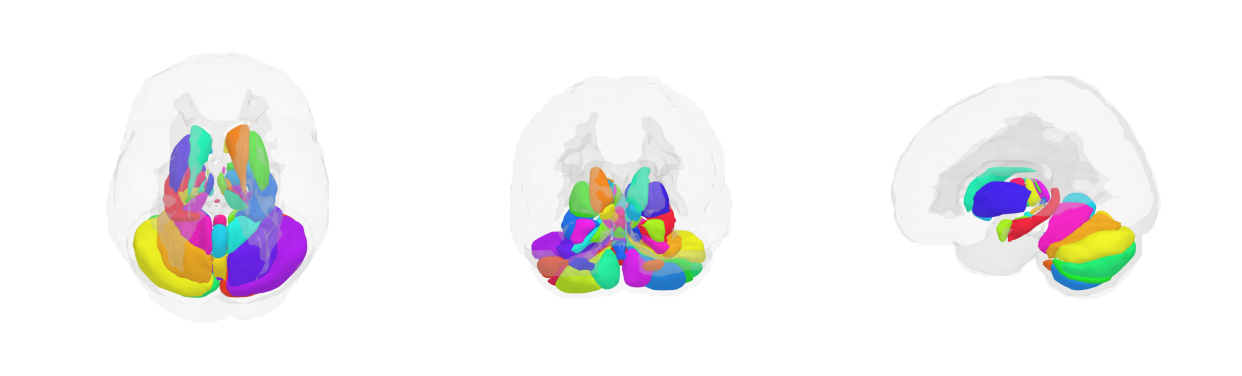

In [5]:
ax = yab.plot_subcortical(
    custom_atlas_path=dir_full_subcortical,
    views=['superior', 'anterior', 'left_lateral'],
    bmesh=bg_mesh,
    bmesh_alpha=0.2,
    bmesh_color='lightgray'
)

# Using a custom background mesh for white matter tracks visualization

In this section, we will apply the same procedure as for the subcortical atlas, but using the `plot_tracts` function to visualize white matter bundles.

## Step 1: Fetch the atlas tracks

For the purpose of this example, we use bundles from an atlas. However, this could also be applied to custom bundles, by using the `custom_atlas_path` argument (similarly to what we did for the subcortical atlas section above). The first steps here are identical to the ones in `docs/tutorials/plotting_tractometry.ipynb`.

In [ ]:
# fetch an example 3D fractional anisotropy (FA) volume from neurovault
fa_url = "https://neurovault.org/media/images/264/JHU-ICBM-FA-2mm.nii.gz"
fa_path = pooch.retrieve(url=fa_url, known_hash=None, path=pooch.os_cache("yabplot"), 
                         fname="sample_fa_map.nii.gz")

# sample the volume across all tracts in the atlas
# this returns a dictionary mapping tract names to their 1D scalar arrays.
tract_data = yab.project_vol2tract_atlas(nii_path=fa_path, atlas="xtract_medium")

## Step 2: Build the background mesh from the FA map

Similar to what we did above, we will use the downloaded FA map to reconstruct a background mesh. One important note here, we need to tweek the `threshold` value to consider the range of possible value on the FA map (range from 0-1). Therefore, the default 0.5 will not work. Setting it to a more conservative value of `0.01` should do the trick. We can also adjust the blurring sigma to a higher value, this will smooth out the boundaries and reduce the effect of noise.

In [20]:
bg_mesh = yab.load_nii_as_mesh(
    nii_path=fa_path,
    smooth_i=20,
    smooth_f=0.1,
    threshold=0.01,
    blur_sigma=3
)

## Step 3: Combine your background mesh and the white matter bundles into a clean figure

To use your background mesh, simply specify your resulting `bg_mesh` to the `bmesh` argument of the `plot_tracts()` function.

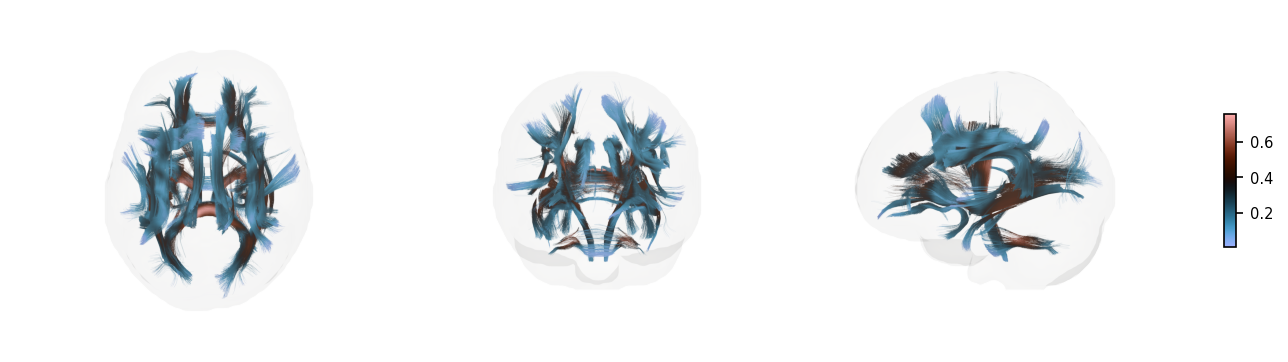

In [21]:
ax = yab.plot_tracts(
    atlas="xtract_medium",
    data=tract_data,
    views=["superior", "anterior", "left_lateral"],
    bmesh=bg_mesh,
    bmesh_alpha=0.2,
    cmap="berlin"
)

## Step 4: Visualize a single tract using the same background mesh.

Now that we have a working background mesh, we can also visualize a single tract using the same method as describe in `docs/tutorials/plotting_tractometry.ipynb`.

Text(0.5, 1.0, 'Single tract (IFOF_L) with custom background mesh')

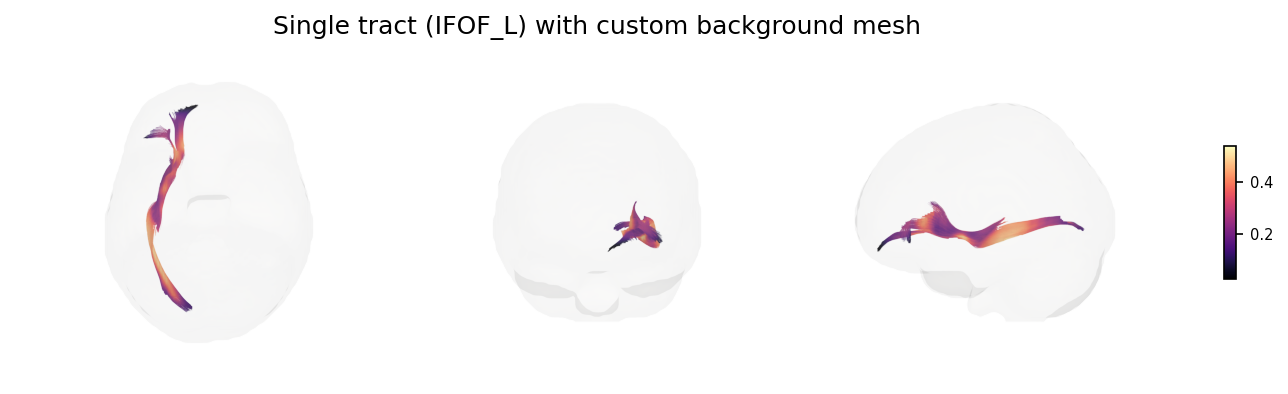

In [23]:
# locate the specific .trk file you want to map
atlas_dir = yab.data._resolve_resource_path('xtract_large', 'tracts')
tract_files = yab.data._find_tract_files(atlas_dir)

# lets get the path to the left inferior fronto-occipital fasciculus (IFOF)
cst_l_path = tract_files['IFOF_L']

# sample the volume for just this one tract and add it to dictionary
sampled_array = yab.project_vol2tract(trk_path=cst_l_path, nii_path=fa_path)
single_tract_data = {'IFOF_L': sampled_array}

ax = yab.plot_tracts(
    atlas="xtract_large",
    data=single_tract_data,
    views=["superior", "anterior", "left_lateral"],
    bmesh=bg_mesh,
    nan_alpha=0.0, # hide other tracts
    bmesh_alpha=0.2,
    cmap="magma"
)
ax.set_title("Single tract (IFOF_L) with custom background mesh")